In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [5]:
df = pd.read_csv("../data/pcos/PCOS_infertility.csv")
df.head()


,Sl. No,Patient File No.,PCOS (Y/N),I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),AMH(ng/mL)
0,1,10001,0,1.99,1.99,2.07
1,2,10002,0,60.80,1.99,1.53
2,3,10003,1,494.08,494.08,6.63
3,4,10004,0,1.99,1.99,1.22
4,5,10005,0,801.45,801.45,2.26


In [6]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3     I   beta-HCG(mIU/mL)  541 non-null    float64
 4   II    beta-HCG(mIU/mL)  541 non-null    float64
 5   AMH(ng/mL)              541 non-null    object 
dtypes: float64(2), int64(3), object(1)
memory usage: 25.5+ KB


In [7]:
df = df.drop(columns=["Sl. No"], errors="ignore")
df.isnull().sum()


Patient File No.          0
PCOS (Y/N)                0
  I   beta-HCG(mIU/mL)    0
II    beta-HCG(mIU/mL)    0
AMH(ng/mL)                0
dtype: int64

In [8]:
X = df.drop("PCOS (Y/N)", axis=1)
y = df["PCOS (Y/N)"]


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


ValueError: could not convert string to float: 'a'

In [11]:
X.select_dtypes(include=['object']).columns


Index(['AMH(ng/mL)'], dtype='object')

In [12]:
for col in X.columns:
    print(col, X[col].unique())


Patient File No. [10001 10002 10003 10004 10005 10006 10007 10008 10009 10010 10011 10012
 10013 10014 10015 10016 10017 10018 10019 10020 10021 10022 10023 10024
 10025 10026 10027 10028 10029 10030 10031 10032 10033 10034 10035 10036
 10037 10038 10039 10040 10041 10042 10043 10044 10045 10046 10047 10048
 10049 10050 10051 10052 10053 10054 10055 10056 10057 10058 10059 10060
 10061 10062 10063 10064 10065 10066 10067 10068 10069 10070 10071 10072
 10073 10074 10075 10076 10077 10078 10079 10080 10081 10082 10083 10084
 10085 10086 10087 10088 10089 10090 10091 10092 10093 10094 10095 10096
 10097 10098 10099 10100 10101 10102 10103 10104 10105 10106 10107 10108
 10109 10110 10111 10112 10113 10114 10115 10116 10117 10118 10119 10120
 10121 10122 10123 10124 10125 10126 10127 10128 10129 10130 10131 10132
 10133 10134 10135 10136 10137 10138 10139 10140 10141 10142 10143 10144
 10145 10146 10147 10148 10149 10150 10151 10152 10153 10154 10155 10156
 10157 10158 10159 10160 10161 101

In [13]:
binary_map = {
    'Yes': 1, 'No': 0,
    'Y': 1, 'N': 0,
    'yes': 1, 'no': 0
}

X = X.replace(binary_map)


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])


In [15]:
X.dtypes


Patient File No.            int64
  I   beta-HCG(mIU/mL)    float64
II    beta-HCG(mIU/mL)    float64
AMH(ng/mL)                  int32
dtype: object

In [17]:
import numpy as np
np.isnan(X_train).sum(), np.isinf(X_train).sum()



TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [18]:
type(X_train)


pandas.core.frame.DataFrame

In [20]:
X_train.dtypes


Patient File No.            int64
  I   beta-HCG(mIU/mL)    float64
II    beta-HCG(mIU/mL)    float64
AMH(ng/mL)                 object
dtype: object

In [21]:
# Convert AMH column to numeric
X_train['AMH(ng/mL)'] = pd.to_numeric(X_train['AMH(ng/mL)'], errors='coerce')
X_test['AMH(ng/mL)'] = pd.to_numeric(X_test['AMH(ng/mL)'], errors='coerce')


In [24]:
X_train['AMH(ng/mL)'].fillna(X_train['AMH(ng/mL)'].median())
X_test['AMH(ng/mL)'].fillna(X_train['AMH(ng/mL)'].median())


229    12.00
73      0.35
352     3.65
86      3.81
470     0.91
       ...  
148     4.00
46      3.66
93      0.86
407     0.90
182     1.35
Name: AMH(ng/mL), Length: 109, dtype: float64

In [25]:
X_train.dtypes


Patient File No.            int64
  I   beta-HCG(mIU/mL)    float64
II    beta-HCG(mIU/mL)    float64
AMH(ng/mL)                float64
dtype: object

In [26]:
X_train_np = X_train.values
np.isnan(X_train_np).sum(), np.isinf(X_train_np).sum()


(0, 0)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [28]:
pcos_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

pcos_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
y_pred = pcos_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7155963302752294
              precision    recall  f1-score   support

           0       0.79      0.82      0.80        77
           1       0.52      0.47      0.49        32

    accuracy                           0.72       109
   macro avg       0.65      0.64      0.65       109
weighted avg       0.71      0.72      0.71       109



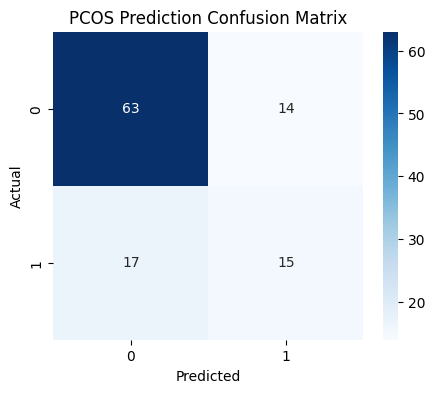

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("PCOS Prediction Confusion Matrix")
plt.show()


In [32]:
import joblib
joblib.dump(pcos_model, "../models/pcos_model.pkl")
joblib.dump(scaler, "../models/pcos_scaler.pkl")


['../models/pcos_scaler.pkl']